Anza Malik FA21-BCS-037

Pakistani Seasonal Color Analysis Overall Testing

---



Step 1: Install Required Libraries

In [ ]:
!pip install mtcnn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 73.1 MB/s eta 0:00:00


Step 2: Load and Display the Image

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load the image
image_path = "/content/3.PNG"  # Replace with your image path
image = cv2.imread(image_path)

# Convert to RGB for display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

Step 3: Detect the Face and Facial Landmarks

In [ ]:
from mtcnn import MTCNN

# Initialize MTCNN
detector = MTCNN()

# Detect faces
faces = detector.detect_faces(image_rgb)

if faces:
    print("Face detected!")
    face_box = faces[0]['box']
    left_eye = faces[0]['keypoints']['left_eye']
    right_eye = faces[0]['keypoints']['right_eye']
    mouth_left = faces[0]['keypoints']['mouth_left']
    mouth_right = faces[0]['keypoints']['mouth_right']

    print("Face Box:", face_box)
    print("Left Eye:", left_eye)
    print("Right Eye:", right_eye)
    print("Mouth Left:", mouth_left)
    print("Mouth Right:", mouth_right)
else:
    print("No face detected in the image.")

Face detected!
Face Box: [9, 0, 90, 111]
Left Eye: [np.int64(28), np.int64(39)]
Right Eye: [np.int64(69), np.int64(34)]
Mouth Left: [np.int64(35), np.int64(83)]
Mouth Right: [np.int64(73), np.int64(78)]


Step 4: Extract Regions of Interest (ROIs)

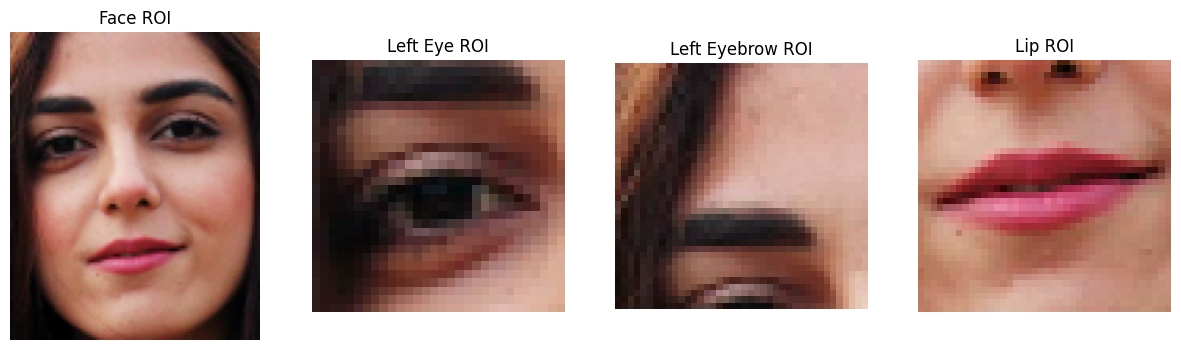

In [ ]:
# Define eyebrow positions (approximate)
left_eyebrow = (left_eye[0], left_eye[1] - 20)
right_eyebrow = (right_eye[0], right_eye[1] - 20)

# Define lip position (center of mouth)
lips = ((mouth_left[0] + mouth_right[0]) // 2, (mouth_left[1] + mouth_right[1]) // 2)

# Function to crop a region around a point
def crop_region(image, center, size=20):
    x, y = center
    h, w, _ = image.shape
    x1, x2 = max(0, x - size), min(w, x + size)
    y1, y2 = max(0, y - size), min(h, y + size)
    return image[y1:y2, x1:x2]

# Crop ROIs
face_roi = image_rgb[face_box[1]:face_box[1]+face_box[3], face_box[0]:face_box[0]+face_box[2]]
left_eye_roi = crop_region(image_rgb, left_eye, size=15)
left_eyebrow_roi = crop_region(image_rgb, left_eyebrow, size=20)
lip_roi = crop_region(image_rgb, lips, size=20)

# Display ROIs
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(face_roi)
axes[0].set_title("Face ROI")
axes[0].axis("off")

axes[1].imshow(left_eye_roi)
axes[1].set_title("Left Eye ROI")
axes[1].axis("off")

axes[2].imshow(left_eyebrow_roi)
axes[2].set_title("Left Eyebrow ROI")
axes[2].axis("off")

axes[3].imshow(lip_roi)
axes[3].set_title("Lip ROI")
axes[3].axis("off")

plt.show()

Step 5: Extract Dominant Colors Using K-Means

In [ ]:
from sklearn.cluster import KMeans

# Function to extract dominant color
def extract_dominant_color(roi, n_colors=1):
    if roi.size == 0:
        return np.array([0, 0, 0])  # Return black if ROI is empty
    pixels = roi.reshape(-1, 3)
    kmeans = KMeans(n_clusters=n_colors, n_init=10)
    kmeans.fit(pixels)
    return kmeans.cluster_centers_.astype(int)[0]  # Return RGB colors only

# Extract dominant colors
face_color = extract_dominant_color(face_roi)
eye_color = extract_dominant_color(left_eye_roi)
eyebrow_color = extract_dominant_color(left_eyebrow_roi)
lip_color = extract_dominant_color(lip_roi)

# Print the extracted colors
print("Face Color (RGB):", face_color)
print("Eye Color (RGB):", eye_color)
print("Eyebrow Color (RGB):", eyebrow_color)
print("Lip Color (RGB):", lip_color)

Face Color (RGB): [138  95  84]
Eye Color (RGB): [96 64 57]
Eyebrow Color (RGB): [134  97  88]
Lip Color (RGB): [182 116 103]


Step 6: Calculate Brightness

In [ ]:
# Function to calculate brightness
def calculate_brightness(r, g, b):
    return (0.299 * r + 0.587 * g + 0.114 * b) / 255

# Calculate brightness
face_brightness = calculate_brightness(*face_color)
eye_brightness = calculate_brightness(*eye_color)
eyebrow_brightness = calculate_brightness(*eyebrow_color)
lip_brightness = calculate_brightness(*lip_color)

# Print brightness values
print("Face Brightness:", face_brightness)
print("Eye Brightness:", eye_brightness)
print("Eyebrow Brightness:", eyebrow_brightness)
print("Lip Brightness:", lip_brightness)

Face Brightness: 0.41805098039215677
Eye Brightness: 0.28537254901960785
Eyebrow Brightness: 0.41975294117647055
Lip Brightness: 0.5264784313725489


Step 7: Prepare Input Features for the Model

In [ ]:
# Prepare the input features
input_features = [
    eye_color[0], eye_color[1], eye_color[2],
    lip_color[0], lip_color[1], lip_color[2],
    eyebrow_color[0], eyebrow_color[1], eyebrow_color[2],
    face_color[0], face_color[1], face_color[2],
    eye_brightness, lip_brightness, eyebrow_brightness, face_brightness
]

print("Input Features:", input_features)

Input Features: [np.int64(96), np.int64(64), np.int64(57), np.int64(182), np.int64(116), np.int64(103), np.int64(134), np.int64(97), np.int64(88), np.int64(138), np.int64(95), np.int64(84), np.float64(0.28537254901960785), np.float64(0.5264784313725489), np.float64(0.41975294117647055), np.float64(0.41805098039215677)]


Step 8: Load the Trained Model and Predict

In [ ]:
import warnings
import pandas as pd
import numpy as np
import joblib

# Suppress the warning
warnings.filterwarnings("ignore", category=UserWarning)

model = joblib.load('random_forest_model.pkl')

# Define feature names (same as during training)
feature_names = [
    'Eye Color_R', 'Eye Color_G', 'Eye Color_B',
    'Lip color_R', 'Lip color_G', 'Lip color_B',
    'Eyebrow Color_R', 'Eyebrow Color_G', 'Eyebrow Color_B',
    'Skin Color_R', 'Skin Color_G', 'Skin Color_B',
    'Eye Color_Brightness', 'Lip color_Brightness',
    'Eyebrow Color_Brightness', 'Skin Color_Brightness'
]


# Ensure feature names match the trained model
feature_names = list(model.feature_names_in_)

# Convert input features to a DataFrame with the correct order
input_df = pd.DataFrame([input_features], columns=feature_names)

# Make a prediction
predicted_season = model.predict(input_df)[0]
print("Prediction:", predicted_season)

Prediction: Winter
